# Task 10 – Advanced GNN Architecture: GATv2

## 10.1 Purpose and Task-Specific Library

GATv2 is selected as the advanced GNN architecture. It learns an attention weight for each neighbouring paper. Its special layer is imported only here.

In [1]:
!pip install -q torch-geometric ogb streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.5 MB/s eta 0:00:00


In [2]:
import os
# Compatibility fix for trusted PyG objects downloaded by the official OGB package on PyTorch 2.6+.
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

for folder in [PROJECT_ROOT, RESULTS_ROOT, MODELS_DIR, SRC_DIR, ARTIFACTS_DIR,
               PROJECT_ROOT / 'notebooks', PROJECT_ROOT / 'visualizations',
               PROJECT_ROOT / 'dashboard', PROJECT_ROOT / 'report',
               PROJECT_ROOT / 'presentation', PROJECT_ROOT / 'video']:
    folder.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/OGBN_Arxiv_Project


In [10]:
import json, random, time, warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device: cpu


In [11]:
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import to_undirected
import torch.serialization
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage

torch.serialization.add_safe_globals([DataEdgeAttr, DataTensorAttr, GlobalStorage])

dataset = PygNodePropPredDataset(name='ogbn-arxiv', root=str(PROJECT_ROOT / 'data'))
data = dataset[0]
x_original = data.x.float()
y = data.y.view(-1).long()
edge_index_directed = data.edge_index.long()
N, E, F_DIM, NUM_CLASSES = data.num_nodes, data.num_edges, data.num_features, dataset.num_classes
print(data)

Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])


In [12]:
from torch_geometric.nn import GATv2Conv

In [13]:
from torch_geometric.utils import subgraph, to_undirected

split = dataset.get_idx_split()
train_idx, valid_idx, test_idx = split['train'].view(-1), split['valid'].view(-1), split['test'].view(-1)
train_mean = x_original[train_idx].mean(0)
train_std = x_original[train_idx].std(0, unbiased=False).clamp_min(1e-8)
x_standardized = (x_original - train_mean) / train_std

generator = torch.Generator().manual_seed(SEED)
def sample_indices(indices, amount):
    return indices[torch.randperm(len(indices), generator=generator)[:min(amount, len(indices))]]

train_sample = sample_indices(train_idx, 12000)
valid_sample = sample_indices(valid_idx, 4000)
test_sample = sample_indices(test_idx, 4000)
selected_nodes = torch.cat([train_sample, valid_sample, test_sample]).unique()

global_to_local = torch.full((N,), -1, dtype=torch.long)
global_to_local[selected_nodes] = torch.arange(len(selected_nodes))
train_local = global_to_local[train_sample]
valid_local = global_to_local[valid_sample]
test_local = global_to_local[test_sample]

full_edges = to_undirected(edge_index_directed, num_nodes=N)
bonus_edges, _ = subgraph(selected_nodes, full_edges, relabel_nodes=True, num_nodes=N)
bonus_x = x_standardized[selected_nodes].to(DEVICE)
bonus_y = y[selected_nodes].to(DEVICE)
bonus_edges = bonus_edges.to(DEVICE)
train_local, valid_local, test_local = train_local.to(DEVICE), valid_local.to(DEVICE), test_local.to(DEVICE)
print('Bonus subgraph:', len(selected_nodes), 'nodes and', bonus_edges.shape[1], 'edges')

Bonus subgraph: 20000 nodes and 32758 edges


In [14]:
class GATv2Network(torch.nn.Module):
    def __init__(self, input_dim, output_dim, dropout=0.4):
        super().__init__()
        self.gat1 = GATv2Conv(input_dim, 16, heads=4, dropout=dropout)
        self.norm = torch.nn.LayerNorm(64)
        self.gat2 = GATv2Conv(64, output_dim, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(self.norm(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.gat2(x, edge_index)

gatv2 = GATv2Network(F_DIM, NUM_CLASSES).to(DEVICE)
print(gatv2)
print('Trainable parameters:', sum(p.numel() for p in gatv2.parameters() if p.requires_grad))

GATv2Network(
  (gat1): GATv2Conv(128, 16, heads=4)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (gat2): GATv2Conv(64, 40, heads=1)
)
Trainable parameters: 22048


In [15]:
@torch.no_grad()
def bonus_accuracy(model, indices):
    model.eval()
    return (model(bonus_x, bonus_edges)[indices].argmax(1) == bonus_y[indices]).float().mean().item()

def train_bonus_model(model, epochs=40, patience=8):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    history, best_val, best_state, stale = [], -1.0, None, 0
    for epoch in range(1, epochs + 1):
        model.train(); optimizer.zero_grad(set_to_none=True)
        logits = model(bonus_x, bonus_edges)
        loss = criterion(logits[train_local], bonus_y[train_local])
        loss.backward(); optimizer.step()
        train_acc = (logits[train_local].argmax(1) == bonus_y[train_local]).float().mean().item()
        val_acc = bonus_accuracy(model, valid_local)
        history.append({'epoch': epoch, 'loss': loss.item(), 'train_accuracy': train_acc,
                        'validation_accuracy': val_acc})
        if val_acc > best_val:
            best_val, stale = val_acc, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0:
            print(epoch, 'loss', round(loss.item(),4), 'train', round(train_acc,4), 'valid', round(val_acc,4))
        if stale >= patience: break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val

1 loss 2.2696 train 0.4117 valid 0.5635
10 loss 2.1863 train 0.4204 valid 0.5713
20 loss 2.1149 train 0.4293 valid 0.5767
30 loss 2.0618 train 0.4434 valid 0.5807
40 loss 2.0484 train 0.4452 valid 0.5822


,model,subset_nodes,validation_accuracy,test_accuracy
0,GATv2,20000,0.58475,0.57225


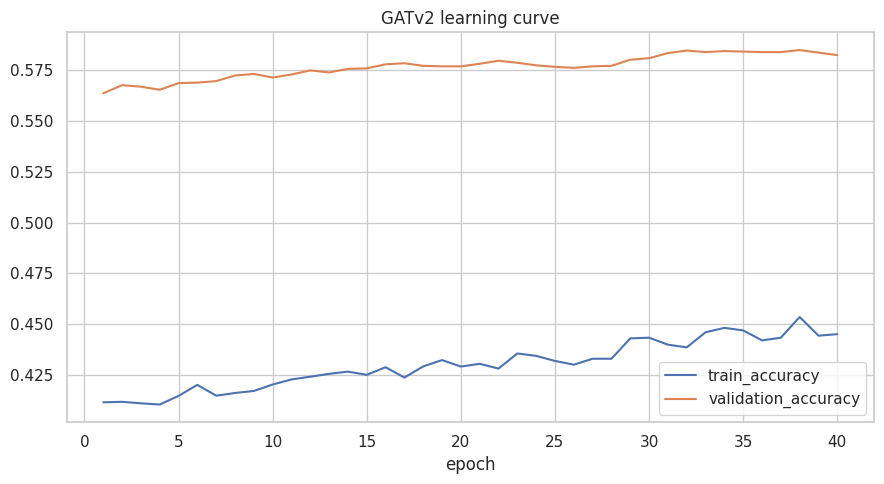

In [17]:
OUTPUT = RESULTS_ROOT

gatv2, history, best_val = train_bonus_model(gatv2)
test_acc = bonus_accuracy(gatv2, test_local)
history.to_csv(OUTPUT / 'gatv2_history.csv', index=False)
torch.save(gatv2.state_dict(), MODELS_DIR / 'bonus_gatv2.pt')
metrics = {'model': 'GATv2', 'subset_nodes': len(selected_nodes),
           'validation_accuracy': best_val, 'test_accuracy': test_acc}
(OUTPUT / 'gatv2_metrics.json').write_text(json.dumps(metrics, indent=2))
display(pd.DataFrame([metrics]))
history.plot(x='epoch', y=['train_accuracy','validation_accuracy'], figsize=(9,5))
plt.title('GATv2 learning curve'); plt.tight_layout()
plt.savefig(OUTPUT / 'gatv2_learning_curve.png', dpi=250); plt.show()

## 10.2 Interpretation

GATv2 can give different importance to different citations. The experiment uses the same sampled data as Task 09, which makes the two bonus attention models comparable with each other. It does not create a fair comparison with the compulsory full-graph models.